# PART A: HANDLING MISSING VALUES

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import zscore

### 🔹 Load Dataset

In [4]:
df = pd.read_csv("patient_health_records.csv")
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,58.0,NaN,West,19.26,120.24,250.52,90.32,0
1,P0002,71.0,Female,North,21.14,118.70,122.78,118.46,0
2,P0003,48.0,Male,West,32.00,143.52,180.90,89.13,1
3,P0004,34.0,Female,East,22.72,139.36,NaN,84.76,1
4,P0005,62.0,Male,North,20.77,132.11,207.67,93.89,1


## 🔹 Part A: Handling Missing Values

In [5]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percent
})

summary

,Missing Values,Percentage (%)
patient_id,0,0.0
age,50,10.0
gender,40,8.0
region,35,7.0
bmi,45,9.0
blood_pressure,0,0.0
cholesterol,40,8.0
glucose,40,8.0
disease_risk,0,0.0


### 🔹 Simple Imputer (Numerical)
Mean or median imputation is used to fill missing BMI values, helping maintain the overall data distribution.

In [7]:
mean_imputer = SimpleImputer(strategy='mean')

df['bmi'] = mean_imputer.fit_transform(df[['bmi']])

print("After MEAN Imputation (BMI):")
print(df[['bmi']].head())

After MEAN Imputation (BMI):
     bmi
0  19.26
1  21.14
2  32.00
3  22.72
4  20.77


### 🔹 Simple Imputer (Categorical)
Missing values in categorical columns like region are replaced using the most frequent category to retain consistency.

In [8]:
freq_imputer = SimpleImputer(strategy='most_frequent')

df['region'] = freq_imputer.fit_transform(df[['region']]).ravel()

print("After MOST FREQUENT Imputation (Region):")
print(df[['region']].head())

print("Most frequent value learned:", freq_imputer.statistics_)

After MOST FREQUENT Imputation (Region):
  region
0   West
1  North
2   West
3   East
4  North
Most frequent value learned: ['South']


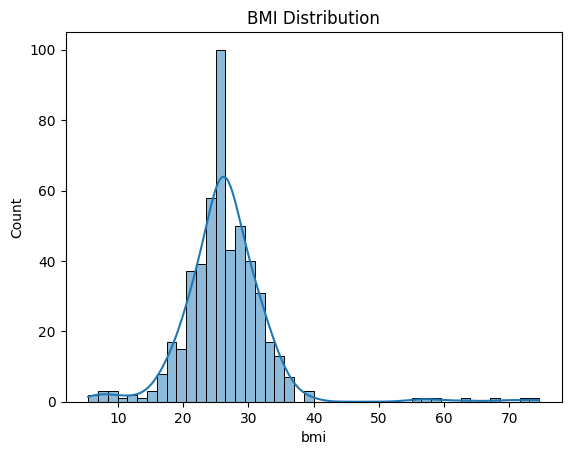

In [25]:
plt.figure()
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

### 🔹 Most Frequent Imputation
Missing values in the gender column are filled with the most common category present in the dataset.

In [9]:
mf_imputer = SimpleImputer(strategy='most_frequent')

df['gender'] = mf_imputer.fit_transform(df[['gender']]).ravel()

print("After MOST FREQUENT Imputation (Gender):")
print(df[['gender']].head())

print("Most frequent value learned:", mf_imputer.statistics_)

After MOST FREQUENT Imputation (Gender):
   gender
0    Male
1  Female
2    Male
3  Female
4    Male
Most frequent value learned: ['Male']


### 🔹 Missing Indicator + Random Sample Imputation
A binary indicator is created for missing values, and random sampling is used to fill them while preserving data variability.

In [10]:
# ─── Missing Indicator (for age) ───
df['age_missing'] = df['age'].isnull().astype(int)

# ─── Random Sample Imputation ───
random_sample = df['age'].dropna().sample(df['age'].isnull().sum(), random_state=0)

# fill missing values
df.loc[df['age'].isnull(), 'age'] = random_sample.values

print("After Missing Indicator + Random Sampling:")
print(df[['age', 'age_missing']].head())

After Missing Indicator + Random Sampling:
    age  age_missing
0  58.0            0
1  71.0            0
2  48.0            0
3  34.0            0
4  62.0            0


### 🔹 KNN Imputer
KNN imputation fills missing values based on the nearest neighbors, using similarity between data points.

In [11]:
knn_imputer = KNNImputer(n_neighbors=5)

num_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']

df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df[num_cols]),
    columns=num_cols
)

print("After KNN Imputation:")
print(df_knn.head())

After KNN Imputation:
    age    bmi  blood_pressure  cholesterol  glucose
0  58.0  19.26          120.24      250.520    90.32
1  71.0  21.14          118.70      122.780   118.46
2  48.0  32.00          143.52      180.900    89.13
3  34.0  22.72          139.36      207.776    84.76
4  62.0  20.77          132.11      207.670    93.89


### 🔹 MICE Algorithm
MICE imputes missing values by modeling relationships between multiple variables through iterative predictions.

In [13]:
mice_imputer = IterativeImputer(random_state=0)

num_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']

df_mice = pd.DataFrame(
    mice_imputer.fit_transform(df[num_cols]),
    columns=num_cols
)

print("After MICE Imputation:")
print(df_mice.head())

After MICE Imputation:
    age    bmi  blood_pressure  cholesterol  glucose
0  58.0  19.26          120.24    250.52000    90.32
1  71.0  21.14          118.70    122.78000   118.46
2  48.0  32.00          143.52    180.90000    89.13
3  34.0  22.72          139.36    205.14003    84.76
4  62.0  20.77          132.11    207.67000    93.89


## 🔹 Part B: Handling Outliers

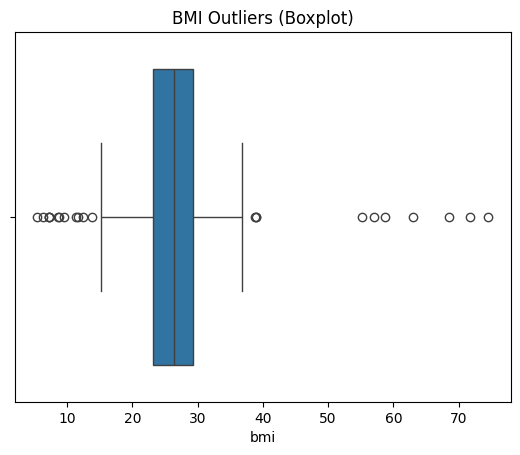

In [14]:
plt.figure()
sns.boxplot(x=df['bmi'])
plt.title("BMI Outliers (Boxplot)")
plt.show()

### 🔹 Z-score Method
Z-score identifies extreme values by measuring how far data points are from the mean, helping detect outliers in cholesterol and glucose.

In [15]:
df_zscore = df.dropna(subset=['cholesterol', 'glucose']).copy()

df_zscore['chol_z'] = zscore(df_zscore['cholesterol'])
df_zscore['glucose_z'] = zscore(df_zscore['glucose'])

# Filter outliers (|z| <= 3) ─
df_z = df_zscore[
    (np.abs(df_zscore['chol_z']) <= 3) &
    (np.abs(df_zscore['glucose_z']) <= 3)
]

df_z = df_z.drop(columns=['chol_z', 'glucose_z'])


print("Original Shape:", df.shape)
print("After Z-score:", df_z.shape)

print("\nSample Data:")
print(df_z.head())

Original Shape: (500, 10)
After Z-score: (399, 10)

Sample Data:
  patient_id   age  gender region    bmi  blood_pressure  cholesterol  \
0      P0001  58.0    Male   West  19.26          120.24       250.52   
1      P0002  71.0  Female  North  21.14          118.70       122.78   
2      P0003  48.0    Male   West  32.00          143.52       180.90   
4      P0005  62.0    Male  North  20.77          132.11       207.67   
5      P0006  27.0    Male   East  28.68          105.40       202.70   

   glucose  disease_risk  age_missing  
0    90.32             0            0  
1   118.46             0            0  
2    89.13             1            0  
4    93.89             1            0  
5    91.39             0            0  


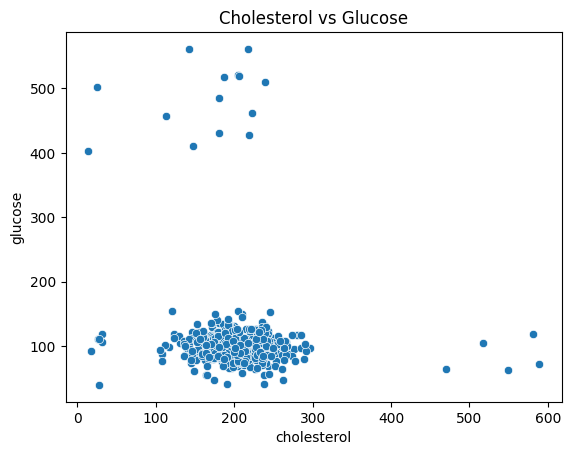

In [16]:
plt.figure()
sns.scatterplot(x=df['cholesterol'], y=df['glucose'])
plt.title("Cholesterol vs Glucose")
plt.show()

### 🔹 IQR Method
The IQR method detects outliers using the spread between quartiles, making it effective for identifying unusual BMI values.

In [17]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df[(df['bmi'] >= lower) & (df['bmi'] <= upper)]

print("After IQR:", df_iqr.shape)

After IQR: (478, 10)


### 🔹 Percentile Method
This method caps or removes values below the 1st percentile and above the 99th percentile to control extreme variations.

In [18]:
lower = df['bmi'].quantile(0.01)
upper = df['bmi'].quantile(0.99)

df_pct = df[(df['bmi'] >= lower) & (df['bmi'] <= upper)]

print("After Percentile:", df_pct.shape)

After Percentile: (490, 10)


### 🔹 Winsorization
Winsorization limits extreme values by capping them within a fixed range instead of removing them from the dataset.

In [19]:
lower = df['bmi'].quantile(0.01)
upper = df['bmi'].quantile(0.99)

df['bmi_winsor'] = df['bmi'].clip(lower, upper)

print(df[['bmi', 'bmi_winsor']].head())

     bmi  bmi_winsor
0  19.26       19.26
1  21.14       21.14
2  32.00       32.00
3  22.72       22.72
4  20.77       20.77


### 🔹 Before vs After Comparison
Comparing dataset shape and summary before and after outlier treatment helps evaluate the impact of data cleaning.

In [20]:
print("Original Shape:", df.shape)
print("After Z-score:", df_z.shape)
print("After IQR:", df_iqr.shape)
print("After Percentile:", df_pct.shape)

print("\nBefore Summary:")
print(df.describe())

print("\nAfter (IQR) Summary:")
print(df_iqr.describe())

Original Shape: (500, 11)
After Z-score: (399, 10)
After IQR: (478, 10)
After Percentile: (490, 10)

Before Summary:
              age         bmi  blood_pressure  cholesterol     glucose  \
count  500.000000  500.000000      500.000000   460.000000  460.000000   
mean    50.666000   26.427165      120.267520   202.601065  111.282065   
std     17.214503    6.821027       22.111116    58.678080   71.243815   
min     20.000000    5.460000       30.270000    13.730000   39.880000   
25%     37.000000   23.167500      109.420000   174.702500   86.607500   
50%     52.000000   26.427165      120.045000   201.775000   99.675000   
75%     65.000000   29.257500      130.565000   226.635000  112.845000   
max     79.000000   74.540000      246.440000   588.870000  561.360000   

       disease_risk  age_missing  bmi_winsor  
count    500.000000     500.0000  500.000000  
mean       0.402000       0.1000   26.344193  
std        0.490793       0.3003    6.172707  
min        0.000000       0.

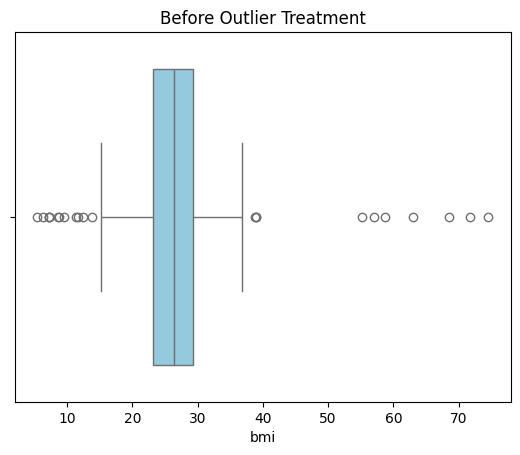

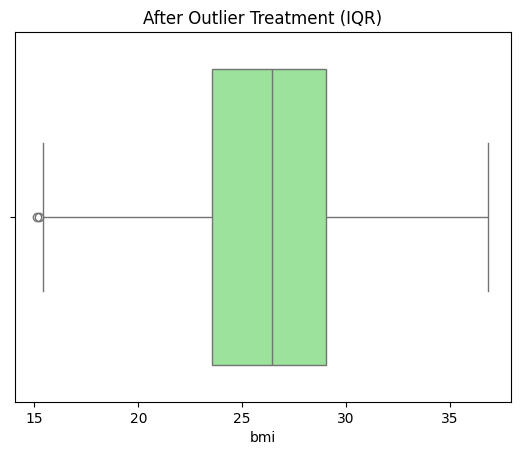

In [23]:
plt.figure()
sns.boxplot(x=df['bmi'], color='skyblue')
plt.title("Before Outlier Treatment")
plt.show()

plt.figure()
sns.boxplot(x=df_iqr['bmi'], color='lightgreen')
plt.title("After Outlier Treatment (IQR)")
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      500 non-null    object 
 1   age             500 non-null    float64
 2   gender          500 non-null    object 
 3   region          500 non-null    object 
 4   bmi             500 non-null    float64
 5   blood_pressure  500 non-null    float64
 6   cholesterol     460 non-null    float64
 7   glucose         460 non-null    float64
 8   disease_risk    500 non-null    int64  
 9   age_missing     500 non-null    int64  
 10  bmi_winsor      500 non-null    float64
dtypes: float64(6), int64(2), object(3)
memory usage: 43.1+ KB


## 🔹 Brief Report

The most effective imputation strategy was using mean for numerical data and most frequent for categorical data, as it handled missing values efficiently.  

The IQR method was the best for outlier handling because it is robust and works well even when data is not normally distributed.  

Z-score removed more values but was more aggressive compared to IQR.  

Data cleaning helped in removing inconsistencies and extreme values from the dataset.

It improved the overall data quality and reliability.

The dataset became more stable and suitable for analysis.

This preprocessing step ensures better performance of machine learning models.  

Overall, data cleaning made the dataset more accurate and usable.